# Burned Areas in Portugal via WFS


This notebook demonstrates how to connect to the [ICNF](https://www.icnf.pt/) Web Feature Service (WFS) that publishes burned areas in Portugal and display the results on a map.

- **Capabilities**: https://si.icnf.pt/wfs/areas_ardidas?version=2.0.0&request=GetCapabilities
- **Metadata catalogue**: https://snig.dgterritorio.gov.pt/rndg/srv/por/catalog.search#/search?keyword=Incêndios%20florestais


**Requirements**

This workflow relies on `geopandas`, `requests`, `matplotlib`, and their dependencies (GDAL/Fiona). If you are running this in a fresh environment, uncomment the cell below to install what is needed.

**Inspect the service**

We start by retrieving the GetCapabilities document to understand which layers (feature types) the service exposes.


In [1]:
import requests
from xml.etree import ElementTree as ET

CAPABILITIES_URL = (
    "https://si.icnf.pt/wfs/areas_ardidas?service=WFS&version=2.0.0&request=GetCapabilities"
)

response = requests.get(CAPABILITIES_URL, timeout=60)
response.raise_for_status()
root = ET.fromstring(response.content)
ns = {"wfs": "http://www.opengis.net/wfs/2.0", "ows": "http://www.opengis.net/ows/1.1"}

layers = []
for feature_type in root.findall('.//wfs:FeatureType', ns):
    name = feature_type.findtext('wfs:Name', namespaces=ns) or ""
    title = feature_type.findtext('wfs:Title', namespaces=ns) or ""
    if 'ardida_' in name:
        layers.append((name, title))

print(f'Found {len(layers)} burned-area layers:')
for name, title in layers:
    print(f' - {name}: {title}')


Found 19 burned-area layers:
 - BDG:ardida_2009: Territórios ardidos (área ardida ano 2009)
 - BDG:ardida_2010: Territórios ardidos (área ardida ano 2010)
 - BDG:ardida_2011: Territórios ardidos (área ardida ano 2011)
 - BDG:ardida_2012: Territórios ardidos (área ardida ano 2012)
 - BDG:ardida_2013: Territórios ardidos (área ardida ano 2013)
 - BDG:ardida_2014: Territórios ardidos (área ardida ano 2014)
 - BDG:ardida_2015: Territórios ardidos (área ardida ano 2015)
 - BDG:ardida_2016: Territórios ardidos (área ardida ano 2016)
 - BDG:ardida_2017: Territórios ardidos (área ardida ano 2017)
 - BDG:ardida_2018: Territórios ardidos (área ardida ano 2018)
 - BDG:ardida_2019: Territórios ardidos (área ardida ano 2019)
 - BDG:ardida_2020: Territórios ardidos (área ardida ano 2020)
 - BDG:ardida_2021: Territórios ardidos (área ardida ano 2021)
 - BDG:ardida_2022: Territórios ardidos (área ardida ano 2022)
 - BDG:ardida_2023: Territórios ardidos (área ardida ano 2023)
 - BDG:ardida_2024: Territ

**Download multiple years into a combined dataset**

In [7]:
import geopandas as gpd
import pandas as pd

WFS_URL = "https://si.icnf.pt/wfs/areas_ardidas"

# Define multiple years to fetch
YEARS = [2020, 2021, 2022, 2023, 2024]
# Or use all available years from the capabilities
# YEARS = [int(name.split('_')[-1]) for name, _ in layers]

all_gdfs = []

for year in YEARS:
    layer_name = f"BDG:ardida_{year}"

    params = {
        "service": "WFS",
        "version": "2.0.0",
        "request": "GetFeature",
        "typeNames": layer_name,
        "outputFormat": "application/json",
        "srsName": "EPSG:4326",
        "count": 10000,
    }

    print(f"Fetching {layer_name}...")

    try:
        response = requests.get(WFS_URL, params=params, timeout=120)

        # Fallback for WFS 1.x compatibility
        if response.status_code == 400:
            fallback_params = params.copy()
            fallback_params["typeName"] = fallback_params.pop("typeNames")
            response = requests.get(WFS_URL, params=fallback_params, timeout=120)

        response.raise_for_status()
        payload = response.json()
        features = payload.get("features", [])

        if features:
            year_gdf = gpd.GeoDataFrame.from_features(features, crs="EPSG:4326")
            year_gdf["year"] = year  # Add year column for tracking
            all_gdfs.append(year_gdf)
            print(f"  Retrieved {len(year_gdf)} burned areas from {year}")
        else:
            print(f"  No features found for {year}")

    except Exception as e:
        print(f"  Error fetching {year}: {e}")

# Combine all years into a single GeoDataFrame
if all_gdfs:
    gdf_wildfires = gpd.GeoDataFrame(
        pd.concat(all_gdfs, ignore_index=True), crs="EPSG:4326"
    )
    print(
        f"\nCombined dataset: {len(gdf_wildfires)} burned areas across {len(YEARS)} years"
    )

    # Save to file for future use
    output_file = "data/portugal_burned_areas_2020_2024.gpkg"
    gdf_wildfires.to_file(output_file, driver="GPKG")
    print(f"Saved to {output_file}")

    gdf_wildfires.head()
else:
    print("\nNo data retrieved")
    gdf_wildfires = None

Fetching BDG:ardida_2020...
  Retrieved 1777 burned areas from 2020
Fetching BDG:ardida_2021...
  Retrieved 918 burned areas from 2021
Fetching BDG:ardida_2022...
  Retrieved 1786 burned areas from 2022
Fetching BDG:ardida_2023...
  Retrieved 1736 burned areas from 2023
Fetching BDG:ardida_2024...
  Retrieved 1558 burned areas from 2024

Combined dataset: 7775 burned areas across 5 years
Saved to data/portugal_burned_areas_2020_2024.gpkg


**Plot the burned areas on a map**

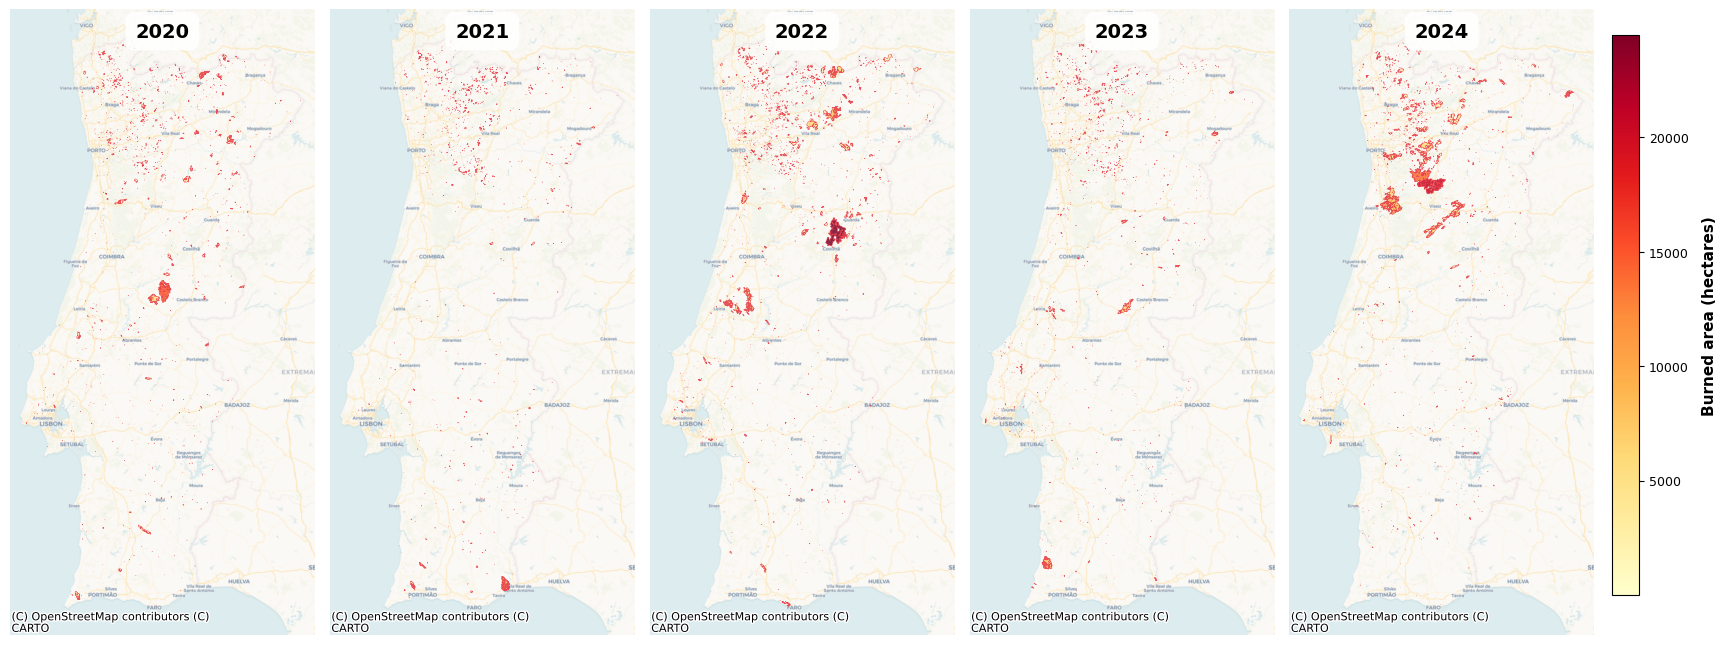


Burned Area Summary:
  2020: 1,777 areas, 66,167 ha total
  2021: 918 areas, 27,375 ha total
  2022: 1,786 areas, 115,149 ha total
  2023: 1,736 areas, 34,146 ha total
  2024: 1,558 areas, 139,397 ha total


In [17]:
import contextily as cx
import matplotlib.pyplot as plt

YEARS_TO_PLOT = [2020, 2021, 2022, 2023, 2024]

# Create figure with 5 subplots
fig, axes = plt.subplots(1, 5, figsize=(18, 14))

# Find global min/max for consistent color scale
all_areas = gdf_wildfires[gdf_wildfires["year"].isin(YEARS_TO_PLOT)]["AreaHaSIG"]
vmin, vmax = all_areas.min(), all_areas.max()

# Calculate common bounds across all years (in Web Mercator)
all_data = gdf_wildfires[gdf_wildfires["year"].isin(YEARS_TO_PLOT)].to_crs(epsg=3857)
xmin, ymin, xmax, ymax = all_data.total_bounds

# Add padding (5%)
x_margin = (xmax - xmin) * 0.05
y_margin = (ymax - ymin) * 0.05
xmin -= x_margin
xmax += x_margin
ymin -= y_margin
ymax += y_margin

for idx, year in enumerate(YEARS_TO_PLOT):
    ax = axes[idx]

    # Filter data for this year
    gdf_year = gdf_wildfires[gdf_wildfires["year"] == year]
    plot_data = gdf_year.to_crs(epsg=3857)

    # Plot burned areas
    plot_data.plot(
        ax=ax,
        column="AreaHaSIG",
        cmap="YlOrRd",
        linewidth=0.3,
        edgecolor="#E63946",
        legend=False,
        alpha=0.85,
        vmin=vmin,
        vmax=vmax,
    )

    # Set common bounds for all subplots
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    # Add contextily basemap
    cx.add_basemap(
        ax,
        crs=plot_data.crs.to_string(),
        source=cx.providers.CartoDB.Voyager,
        alpha=0.8,
    )

    ax.text(
        0.5,
        0.98,
        f"{year}",
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        ha="center",
        va="top",
        bbox=dict(
            boxstyle="round,pad=0.5", facecolor="white", edgecolor="none", alpha=0.9
        ),
    )

    ax.set_axis_off()
    # Set equal aspect ratio
    ax.set_aspect("equal", adjustable="box")

# Add a single colorbar on the right side
cbar_ax = fig.add_axes([0.91, 0.29, 0.015, 0.4])

sm = plt.cm.ScalarMappable(cmap="YlOrRd", norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])

cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Burned area (hectares)", fontsize=11, fontweight="bold", labelpad=10)
cbar.ax.tick_params(labelsize=9)

plt.subplots_adjust(left=0.02, right=0.90, top=0.95, bottom=0.02, wspace=0.05)
plt.show()

# Print summary statistics
print("\nBurned Area Summary:")
for year in YEARS_TO_PLOT:
    year_data = gdf_wildfires[gdf_wildfires["year"] == year]
    total_area = year_data["AreaHaSIG"].sum()
    count = len(year_data)
    print(f"  {year}: {count:,} areas, {total_area:,.0f} ha total")